**Accidents in Philadelphia - What can we learn from them?**

Every city has its rhythms. Morning rush, late-night quiets and weekend energy. But what if we looked at those rhythms through a different lens? Instead of traffic flow, we look at traffic crashes.

Using nearly two decades of PDOT crash data, we will try uncover patterns to answer questions like: 

Are crashes really worse during rush hour?

Do weekends make roads more dangerous?

Has safety improved over time?

Let’s dive in.


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("PDOT_crash_data_2005_2024.csv")
df.head()

/tmp/ipykernel_3094128/423130451.py:3: DtypeWarning: Columns (0: INTERSECTION_RELATED, 1: SECONDARY_CRASH, 2: WZ_CLOSE_DETOUR, 3: WZ_WORKERS_INJ_KILLED) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("PDOT_crash_data_2005_2024.csv")


,CRN,ARRIVAL_TM,AUTOMOBILE_COUNT,BELTED_DEATH_COUNT,BELTED_SUSP_SERIOUS_INJ_COUNT,BICYCLE_COUNT,BICYCLE_DEATH_COUNT,BICYCLE_SUSP_SERIOUS_INJ_COUNT,BUS_COUNT,CHLDPAS_DEATH_COUNT,...,WORK_ZONE_LOC,WORK_ZONE_TYPE,WZ_CLOSE_DETOUR,WZ_FLAGGER,WZ_LAW_OFFCR_IND,WZ_LN_CLOSURE,WZ_MOVING,WZ_OTHER,WZ_SHLDER_MDN,WZ_WORKERS_INJ_KILLED
0,2005000003,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005000044,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005000073,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005001018,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005001021,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
df = df.dropna(subset=["CRASH_YEAR", "HOUR_OF_DAY", "DAY_OF_WEEK"])

df["CRASH_YEAR"] = df["CRASH_YEAR"].astype(int)
df["HOUR_OF_DAY"] = df["HOUR_OF_DAY"].astype(int)

df.head()

,CRN,ARRIVAL_TM,AUTOMOBILE_COUNT,BELTED_DEATH_COUNT,BELTED_SUSP_SERIOUS_INJ_COUNT,BICYCLE_COUNT,BICYCLE_DEATH_COUNT,BICYCLE_SUSP_SERIOUS_INJ_COUNT,BUS_COUNT,CHLDPAS_DEATH_COUNT,...,WORK_ZONE_LOC,WORK_ZONE_TYPE,WZ_CLOSE_DETOUR,WZ_FLAGGER,WZ_LAW_OFFCR_IND,WZ_LN_CLOSURE,WZ_MOVING,WZ_OTHER,WZ_SHLDER_MDN,WZ_WORKERS_INJ_KILLED
0,2005000003,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005000044,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005000073,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005001018,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005001021,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


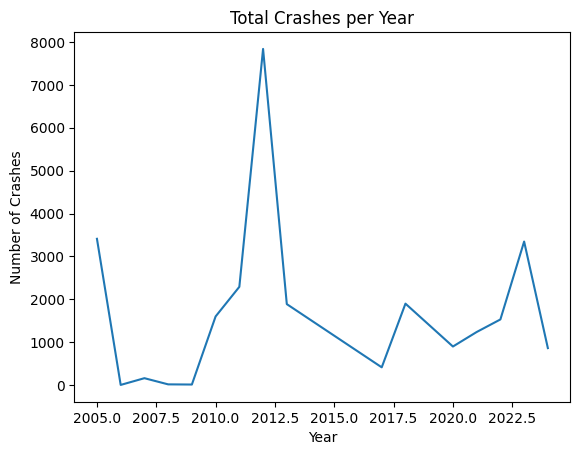

In [45]:
crashes_per_year = df["CRASH_YEAR"].value_counts().sort_index()

plt.figure()
crashes_per_year.plot(kind='line')
plt.title("Total Crashes per Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.show()

At first glance, the trend is not strictly increasing or decreasing — instead, it fluctuates.

But here’s the interesting twist:

There are noticeable dips in certain years, and a huge spike in 2012. (https://www.cnn.com/2012/07/23/travel/us-traffic-fatalities) 

The reason for this spike is unclear but is hypothesized to be events of extreme weather. Realistically, though, I am of the opinion that even several extreme weather events are unlikely to cause such a huge hike in crashes. 

A more reasonable and expected pattern in the data above is the dip in 2020. These dips often align with external disruptions (like reduced travel periods).

This suggests something important: Crash frequency is strongly tied to human activity levels. The pandemic led to a widespread lockdown in 2020, resulting in a sharp decline in road traffic and, consequently, in crashes. 

Fewer people on the road → fewer crashes.

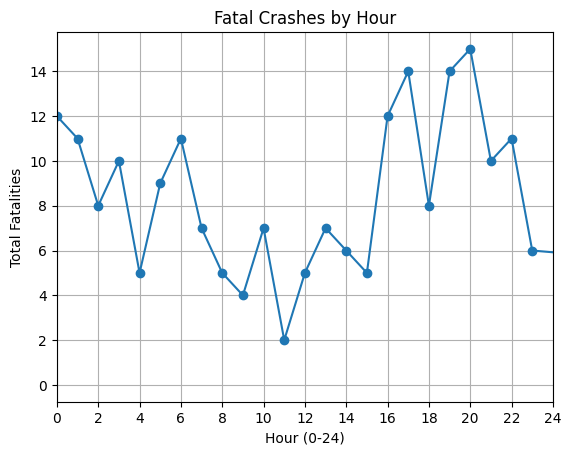

In [46]:
if "FATAL_COUNT" in df.columns:
    fatal_by_hour = df.groupby("HOUR_OF_DAY")["FATAL_COUNT"].sum()

    fatal_by_hour.plot(kind='line', marker='o')
    plt.title("Fatal Crashes by Hour")
    plt.xlabel("Hour (0-24)")
    plt.ylabel("Total Fatalities")
    
    plt.xlim(0, 24)
    plt.xticks(range(0, 25, 2))
    plt.grid(True)
    
    plt.savefig("fatal_crashes_by_hour.png")

This is fascinating. There is a vague but visible U-shape. Fatal crashes more often take place in the first few hours of the day, and the last few hours of the day, with a particular emphasizes on the last few hours. 

Now this makes intuitive sense! Dark surroundings and low-visiblity often cause terrible accidents that lead to fatalities. 

Morning rush hour (6 - 9 am): 22

Evening rush hour (4 - 7 pm): 48

There's a huge difference! The evening rush hour, featuring high traffic and often taking place after sunset, is when a bulk of accidents take place. 

<Axes: xlabel='DAY_NAME'>

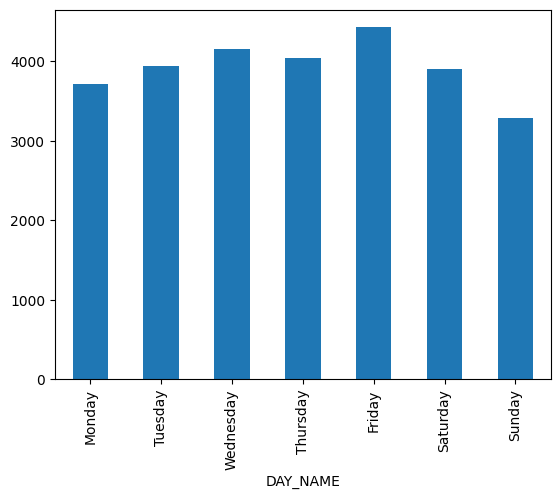

In [47]:
day_map = {1: "Sunday", 2: "Monday", 3: "Tuesday", 4: "Wednesday", 
           5: "Thursday", 6: "Friday", 7: "Saturday"}

df["DAY_NAME"] = df["DAY_OF_WEEK"].map(day_map)

# 2. Now count the occurrences of the names
crashes_by_day = df["DAY_NAME"].value_counts()

# 3. Reindex using the list of names
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
crashes_by_day = crashes_by_day.reindex(order)

# 4. Plot (this will now work!)
crashes_by_day.plot(kind='bar')

Sometimes no observable patterns are also an importance thing to note. There isn't any clear indication that certain days of the week are busier and involve more accidents.

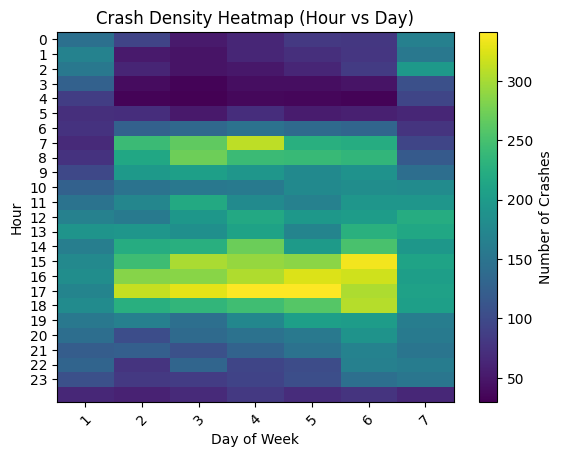

In [48]:
pivot = df.pivot_table(index="HOUR_OF_DAY", columns="DAY_OF_WEEK", aggfunc="size")

plt.figure()
plt.imshow(pivot, aspect='auto')
plt.colorbar(label="Number of Crashes")
plt.title("Crash Density Heatmap (Hour vs Day)")
plt.xlabel("Day of Week")
plt.ylabel("Hour")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(0,24))
plt.show()

This heatmap reveals a clear "rush hour" correlation, with the highest crash density (indicated by the yellow bands) occurring between 3:00 PM and 6:00 PM (Hours 15–18) on weekdays. This suggests that the afternoon commute is significantly more hazardous than the morning peak. While a secondary morning spike is visible around 7:00 AM, it is less intense. Geometrically, the "dark" regions from midnight to 5:00 AM reflect the lowest risk due to reduced traffic volume. Interestingly, the weekend patterns (Days 1 and 7) lack the distinct commuter peaks, showing a more uniform distribution of incidents throughout the afternoon.

In [49]:
df.columns

Index(['CRN', 'ARRIVAL_TM', 'AUTOMOBILE_COUNT', 'BELTED_DEATH_COUNT',
       'BELTED_SUSP_SERIOUS_INJ_COUNT', 'BICYCLE_COUNT', 'BICYCLE_DEATH_COUNT',
       'BICYCLE_SUSP_SERIOUS_INJ_COUNT', 'BUS_COUNT', 'CHLDPAS_DEATH_COUNT',
       'CHLDPAS_SUSP_SERIOUS_INJ_COUNT', 'COLLISION_TYPE', 'COMM_VEH_COUNT',
       'CONS_ZONE_SPD_LIM', 'COUNTY', 'CRASH_MONTH', 'CRASH_YEAR',
       'DAY_OF_WEEK', 'DEC_LATITUDE', 'DEC_LONGITUDE', 'DISPATCH_TM',
       'DISTRICT', 'DRIVER_COUNT_16YR', 'DRIVER_COUNT_17YR',
       'DRIVER_COUNT_18YR', 'DRIVER_COUNT_19YR', 'DRIVER_COUNT_20YR',
       'DRIVER_COUNT_50_64YR', 'DRIVER_COUNT_65_74YR', 'DRIVER_COUNT_75PLUS',
       'EST_HRS_CLOSED', 'FATAL_COUNT', 'HEAVY_TRUCK_COUNT',
       'HORSE_BUGGY_COUNT', 'HOUR_OF_DAY', 'ILLUMINATION', 'INJURY_COUNT',
       'INTERSECTION_RELATED', 'INTERSECT_TYPE', 'LANE_CLOSED', 'LATITUDE',
       'LN_CLOSE_DIR', 'LOCATION_TYPE', 'LONGITUDE', 'MAX_SEVERITY_LEVEL',
       'MCYCLE_DEATH_COUNT', 'MCYCLE_SUSP_SERIOUS_INJ_COUNT',
 

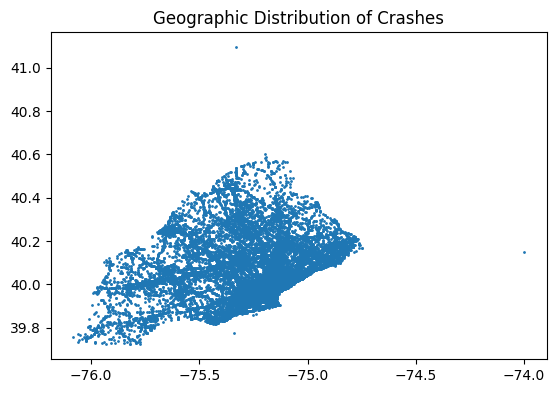

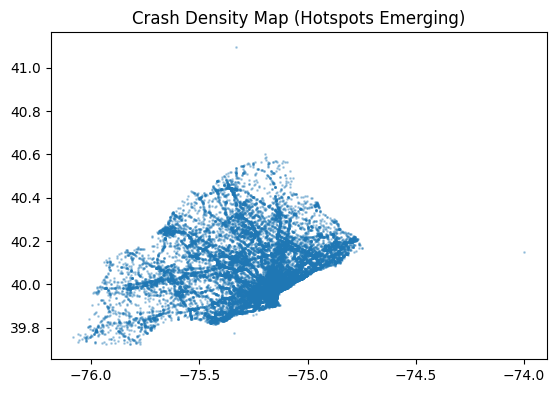

In [52]:
import geopandas as gpd
from shapely.geometry import Point


geometry = [Point(xy) for xy in zip(df["DEC_LONGITUDE"], df["DEC_LATITUDE"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)

# Plot
gdf.plot(markersize=1)
plt.title("Geographic Distribution of Crashes")
plt.show()

gdf.plot(markersize=1, alpha=0.3)

plt.title("Crash Density Map (Hotspots Emerging)")
plt.show()

The above is a reflection of which roads are busier - the ones typically in center city, and the regions with less traffic in surrounding areas where the accident density is lower. 

Pretty cool how this distribution essentially draws a map of the data collection area! 


In [ ]:
**In Conclsio**